In [2]:
import zipfile

with zipfile.ZipFile('superstore dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Extracted Successfully!")

Extracted Successfully!


In [3]:
import os
os.listdir('/content/')

['.config', 'Sample - Superstore.csv', 'superstore dataset.zip', 'sample_data']

In [4]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [5]:
# Load the Dataset
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)

Dataset Loaded Successfully!
Shape: (9994, 21)


In [6]:
# See first 5 rows
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
# Check basic info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract Month and Year
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

print("Date Cleaned Successfully!")
print(df[['Order Date', 'Month', 'Year']].head())

Date Cleaned Successfully!
  Order Date  Month  Year
0 2016-11-08     11  2016
1 2016-11-08     11  2016
2 2016-06-12      6  2016
3 2015-10-11     10  2015
4 2015-10-11     10  2015


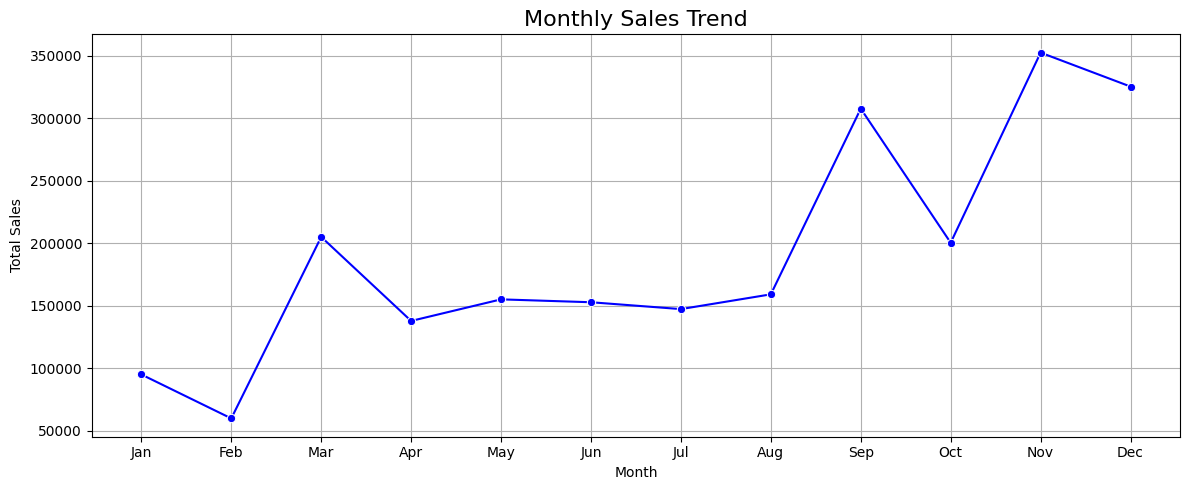

In [9]:
# Monthly Sales Trend
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(12, 5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o', color='blue')
plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2106/2952270319.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yearly_sales.index, y=yearly_sales.values, palette='Blues_d')


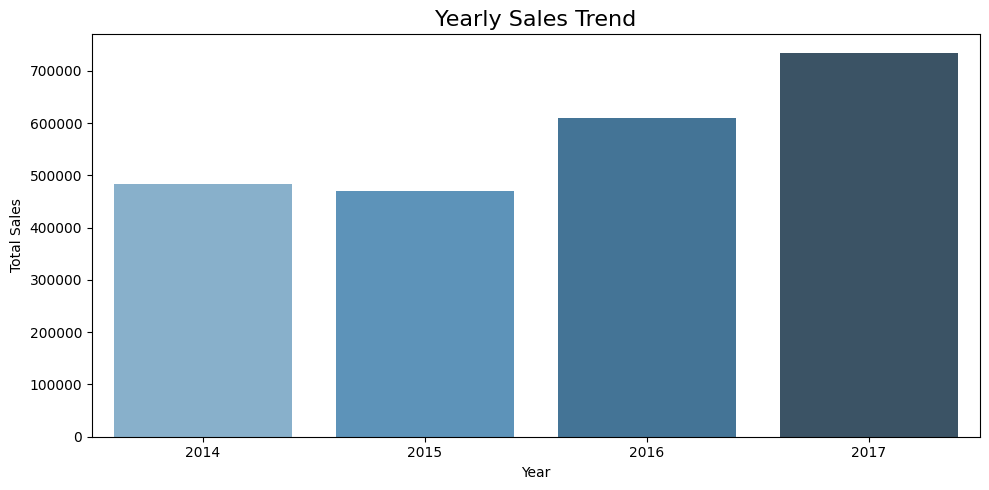

In [10]:
# Yearly Sales Trend
yearly_sales = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(10, 5))
sns.barplot(x=yearly_sales.index, y=yearly_sales.values, palette='Blues_d')
plt.title('Yearly Sales Trend', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2106/1064516367.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette='Set2')


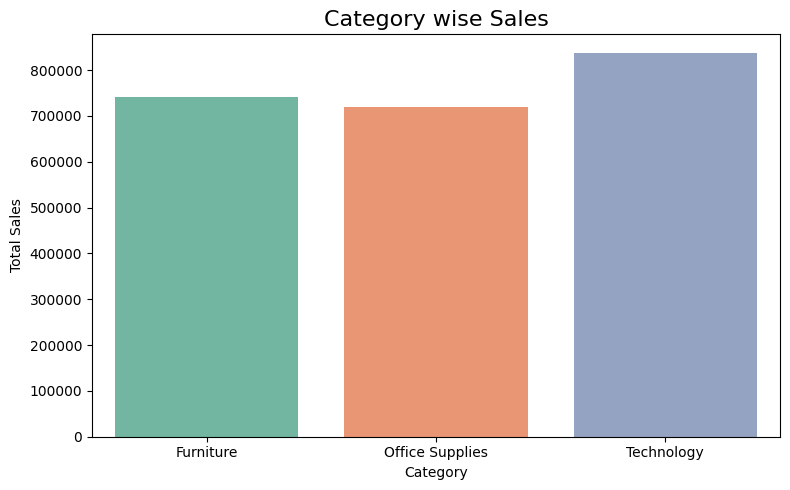

In [11]:
# Category wise Sales
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8, 5))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='Set2')
plt.title('Category wise Sales', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2106/3702853003.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, palette='Set1')


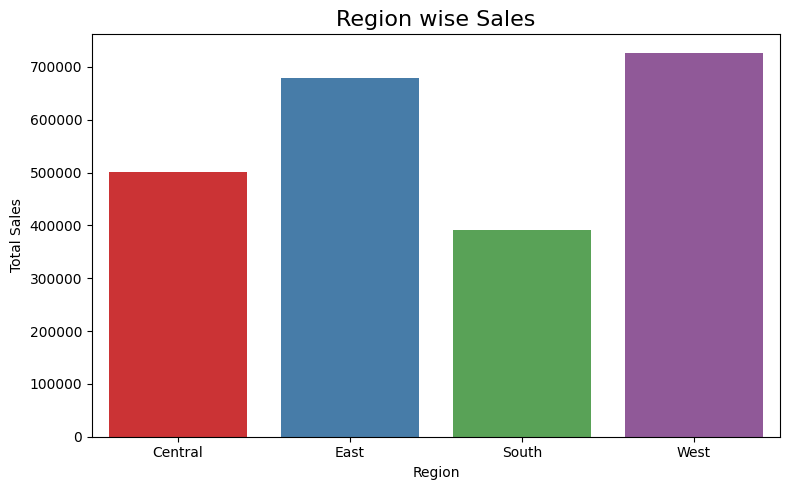

In [12]:
# Region wise Sales
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8, 5))
sns.barplot(x=region_sales.index, y=region_sales.values, palette='Set1')
plt.title('Region wise Sales', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

In [13]:
# Project Summary
print("=" * 50)
print("   SALES TREND VISUALIZATION - SUMMARY")
print("=" * 50)
print(f"Total Records: {df.shape[0]}")
print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Best Month: November")
print(f"Best Year: 2017")
print(f"Top Category: Technology")
print(f"Top Region: West")
print("=" * 50)
print("Project Completed Successfully! ")

   SALES TREND VISUALIZATION - SUMMARY
Total Records: 9994
Total Sales: $2,297,200.86
Best Month: November
Best Year: 2017
Top Category: Technology
Top Region: West
Project Completed Successfully! 
